# Flip simulated trajectories

In [2]:
import torch
import sys
sys.path.append("../")
sys.path.append("../src")
sys.path.append("../src/models")
sys.path.append("../src/data")
sys.path.append("../src/utils")
sys.path.append("../src/data/components/")
sys.path.append("../src/models/components/")
sys.path.append("../src/utils/IEBCS")
sys.path.append("../src/utils/IEBCS/representations")
import eventIO, event_representations
from topspin_datamodule import TopspinDataModule, pad_collate_fn
from topspin_classification_module import TopspinLitModule
from TOPSPIN import Hdf5Dataset
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

/home/lkolmar/anaconda3/envs/learning/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data_module = TopspinDataModule(
    data_dir="/data/lkolmar/datasets/topspin_fit_to_max/",
    time_window=50000,  # in us
    num_bins=10,
    sensor_size=(100, 100),
    train_val_test_split=(1294, 277, 277),  # n = 1848 (70%, 15%, 15%)
    batch_size=1,
    num_workers=4,
    pin_memory=True,
)
data_module.transforms = transforms.Compose([
    # Add any necessary transformations here
    lambda ev: event_representations.create_sequence(ev, 
                                                    data_module.hparams.time_window, data_module.hparams.num_bins, 
                                                    data_module.hparams.sensor_size, flip=True),  # create sequences from events
])
data_module.prepare_data()
data_module.setup()
test_loader = data_module.test_dataloader()


------------------------------------------------------------------------

Train indices: [1590, 1, 1334, 52, 954, 1596, 298, 1188, 78, 440, 1790, 1297, 722, 952, 771, 895, 1347, 1761, 1515, 530, 377, 119, 603, 1434, 323, 1001, 221, 1440, 1255, 1247, 636, 600, 443, 1177, 211, 1792, 755, 1579, 1070, 870, 1810, 800, 985, 362, 1199, 353, 383, 1236, 741, 1041, 1492, 1527, 626, 1647, 1624, 1027, 1399, 665, 376, 421, 1370, 1796, 1652, 313, 510, 427, 171, 1703, 799, 1513, 963, 1226, 1648, 1051, 842, 1805, 1107, 1038, 986, 470, 174, 775, 1408, 426, 1474, 1340, 283, 123, 1083, 1169, 511, 2, 509, 567, 1839, 1830, 625, 944, 459, 308, 554, 1127, 453, 1023, 105, 1812, 1651, 95, 1093, 357, 319, 102, 1343, 1459, 1016, 1189, 840, 1231, 289, 493, 1223, 23, 441, 1769, 916, 80, 1503, 846, 587, 551, 1655, 1101, 980, 1458, 74, 433, 776, 1235, 138, 1714, 979, 1542, 1523, 417, 1207, 700, 1312, 695, 1316, 1184, 1012, 540, 1336, 871, 1478, 642, 546, 431, 1348, 1747, 1206, 731, 937, 1355, 1397, 1604, 1015, 762,

torch.Size([1, 4, 10, 100, 100])
(10, 100, 100)


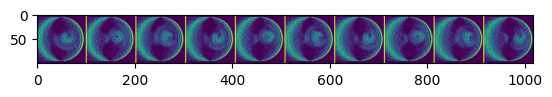

In [5]:
sample = next(iter(test_loader))
print(sample[0].shape)
sample = sample[0][0][2].cpu().numpy()
print(sample.shape)
plt.imshow(event_representations.get_voxel_grid_as_image(sample))
plt.show()